卷积神经网络（LeNet）

LeNet可用于识别图像中的手写数字，由卷积编码器和全连接层密集块组成。每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均汇聚层。

卷积层是四维张量，(batch size, channel, height, width)，进入全连接层之前要将其展平，(batch size, feature number)，整个模型可以通过将各层按顺序连接（Sequential）来实现。

清晰地体现了卷积神经网络的核心思想：

前面用卷积层逐步提取特征（从局部到更抽象），
用池化层降低维度并增强稳定性，
最后用全连接层完成分类。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

下面将一个大小为$28 \times 28$的单通道（黑白）图像通过LeNet，并在每一层打印输出的形状

In [2]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


模型训练

下面验证LeNet在Fashion-MNIST数据集上的表现

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [4]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [5]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.471, train acc 0.823, test acc 0.763
19534.4 examples/sec on cpu


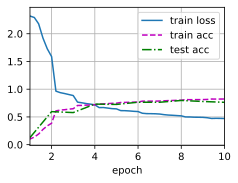

In [6]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 练习

1. 将平均汇聚层替换为最大汇聚层，会发生什么？


最大汇聚层通常比平均汇聚层更容易提取“最显著特征”，因此训练速度和最终准确率往往会更好一些，平均汇聚会把局部区域整体平滑下来；最大汇聚只保留最强响应，所以边缘、纹理、局部突出的模式会更明显。

In [7]:
net_maxpool = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

loss 0.437, train acc 0.837, test acc 0.831
18557.2 examples/sec on cpu


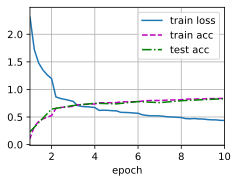

In [8]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

1. 尝试构建一个基于LeNet的更复杂的网络，以提高其准确性。
    1. 调整卷积窗口大小。
    1. 调整输出通道的数量。
    1. 调整激活函数（如ReLU）。
    1. 调整卷积层的数量。
    1. 调整全连接层的数量。
    1. 调整学习率和其他训练细节（例如，初始化和轮数）。


A. 调整卷积窗口大小,改为3*3

In [9]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.419, train acc 0.846, test acc 0.808
18520.3 examples/sec on cpu


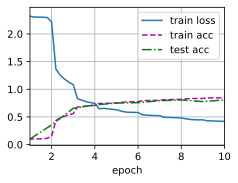

In [10]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

测试准确率从 0.763 → 0.808，有明显提升，说明小卷积核更有效。
3×3 卷积核虽然感受野更小，但可以通过多层堆叠获得更强的表达能力，同时参数更少、更容易训练。

B. 调整输出通道数量，改成32和64

In [11]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=5),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.403, train acc 0.851, test acc 0.820
18642.1 examples/sec on cpu


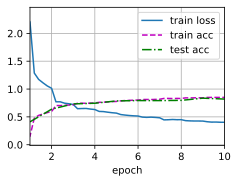

In [12]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

测试准确率进一步提升到 0.820，说明增加通道数有效。通道数增加意味着模型可以学习更多不同类型的特征（边缘、纹理、结构等）。

C. 调整激活函数为ReLU

In [15]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=5),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10))

loss 0.409, train acc 0.850, test acc 0.839
18291.7 examples/sec on cpu


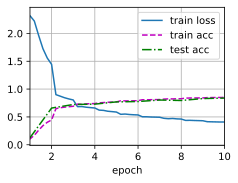

In [16]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

测试准确率提升到 0.839。
ReLU 的优势在于避免梯度消失，收敛更快，稀疏激活（更强表达能力）。
准确率提升说明激活函数对深度网络训练影响很大。

D. 调整卷积层数量，加到三层或四层

In [17]:
net_more_conv = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
    nn.Linear(128, 10)
)

loss 0.404, train acc 0.851, test acc 0.851
18159.0 examples/sec on cpu


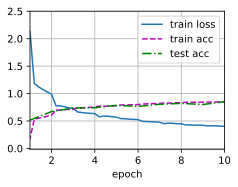

In [18]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

测试准确率达到 0.851，是所有改动中效果最好的。

增加卷积层让模型能够从“低级特征 → 高级特征”逐层抽象

第一层：边缘
第二层：局部形状
第三层：整体结构

说明深度是提升模型能力的核心因素之一。

E. 调整全连接层数量

In [19]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 256), nn.Sigmoid(),
    nn.Linear(256, 10), nn.Sigmoid(),
    nn.Linear(84, 10))

loss 0.404, train acc 0.851, test acc 0.825
17789.7 examples/sec on cpu


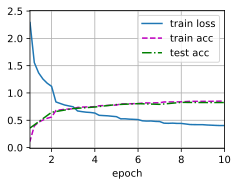

In [20]:
lr, num_epochs = 0.9, 10
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

测试准确率为 0.825，提升不明显

说明
卷积层负责“特征提取”，更重要，
全连接层只是“分类器”，作用有限。改进重点应放在卷积部分，而不是全连接部分。

F. 调整学习率和训练细节

In [21]:
net_more_conv = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
    nn.Linear(128, 10)
)

loss 0.881, train acc 0.677, test acc 0.681
17515.7 examples/sec on cpu


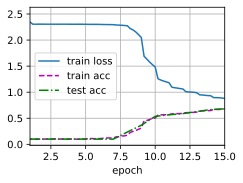

In [22]:
lr, num_epochs = 0.1, 15
train_ch6(net_maxpool, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

性能明显下降，学习率过大或设置不当会导致梯度震荡，无法收敛

1. 显示不同输入（例如毛衣和外套）时，LeNet第一层和第二层的激活值。

提取中间层激活

In [23]:
def get_activations(net, X):
    activations = []
    for i, layer in enumerate(net):
        X = layer(X)
        if isinstance(layer, nn.Conv2d):
            activations.append(X.detach().cpu())
            if len(activations) == 2:
                break
    return activations

从测试集中取毛衣和外套各一张

In [24]:
def get_samples_by_label(data_iter, labels_needed, num_per_label=1):
    samples = {}
    for X, y in data_iter:
        for i in range(len(y)):
            label = int(y[i])
            if label in labels_needed and label not in samples:
                samples[label] = X[i:i+1]
            if len(samples) == len(labels_needed):
                return samples
    return samples

可视化原图和激活图

In [25]:
import matplotlib.pyplot as plt

fashion_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                  'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

def show_feature_maps(img, activations, title_prefix=''):
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze().cpu(), cmap='gray')
    plt.title(f'{title_prefix} input')
    plt.axis('off')
    plt.show()

    for layer_idx, act in enumerate(activations, start=1):
        act = act[0]  # 去掉 batch 维度，形状变成 (C, H, W)
        num_channels = min(act.shape[0], 6)  # 最多显示前6个通道
        fig, axes = plt.subplots(1, num_channels, figsize=(2*num_channels, 2))
        if num_channels == 1:
            axes = [axes]
        for i in range(num_channels):
            axes[i].imshow(act[i], cmap='gray')
            axes[i].set_title(f'L{layer_idx} C{i}')
            axes[i].axis('off')
        plt.show()

loss 0.459, train acc 0.828, test acc 0.813
18630.0 examples/sec on cpu


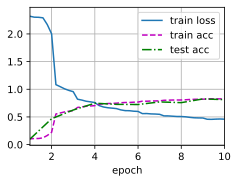

In [27]:
net_lenet = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

lr, num_epochs = 0.9, 10
train_ch6(net_lenet, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [29]:
import torch
from torch import nn
import matplotlib.pyplot as plt

def get_lenet_conv_activations(net, X):
    # 第一层卷积输出
    A1 = net[0](X)

    # 第二层卷积输出：X 经过前 4 层（0,1,2,3）
    X2 = X
    for i in range(4):
        X2 = net[i](X2)
    A2 = X2

    return A1.detach().cpu(), A2.detach().cpu()

In [31]:
def show_feature_maps(img, A1, A2, title_prefix=''):
    # 原图
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze().cpu(), cmap='gray')
    plt.title(f'{title_prefix} input')
    plt.axis('off')
    plt.show()

    # 第一层卷积特征图
    a1 = A1[0]   # 去掉 batch 维
    num1 = min(a1.shape[0], 6)
    fig, axes = plt.subplots(1, num1, figsize=(2 * num1, 2))
    if num1 == 1:
        axes = [axes]
    for i in range(num1):
        axes[i].imshow(a1[i], cmap='gray')
        axes[i].set_title(f'Conv1-{i}')
        axes[i].axis('off')
    plt.show()

    # 第二层卷积特征图
    a2 = A2[0]
    num2 = min(a2.shape[0], 6)
    fig, axes = plt.subplots(1, num2, figsize=(2 * num2, 2))
    if num2 == 1:
        axes = [axes]
    for i in range(num2):
        axes[i].imshow(a2[i], cmap='gray')
        axes[i].set_title(f'Conv2-{i}')
        axes[i].axis('off')
    plt.show()

In [32]:
fashion_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                  'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

def get_samples_by_label(data_iter, labels_needed):
    samples = {}
    for X, y in data_iter:
        for i in range(len(y)):
            label = int(y[i])
            if label in labels_needed and label not in samples:
                samples[label] = X[i:i+1]   # 保留 batch 维度
            if len(samples) == len(labels_needed):
                return samples
    return samples

运行可视化

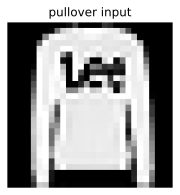

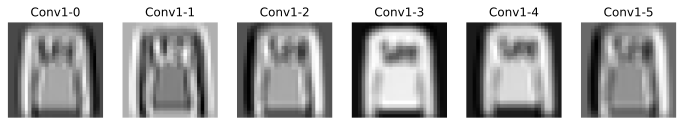

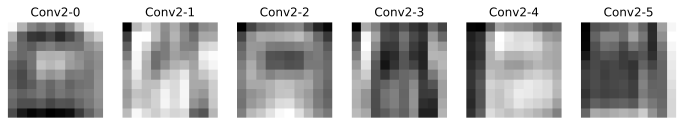

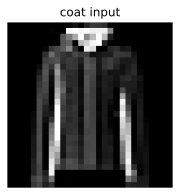

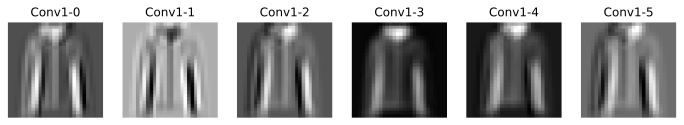

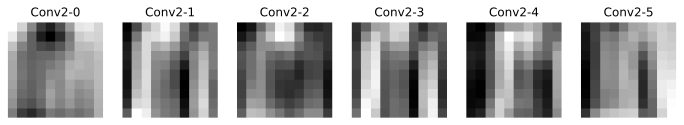

In [33]:
device = d2l.try_gpu()
net_lenet.to(device)
net_lenet.eval()

samples = get_samples_by_label(test_iter, labels_needed=[2, 4])

for label, img in samples.items():
    img_device = img.to(device)
    A1, A2 = get_lenet_conv_activations(net_lenet, img_device)
    show_feature_maps(img, A1, A2, title_prefix=fashion_labels[label])

从图中可以观察到：

第一层（Conv1）：提取边缘、轮廓，不同类别响应较相似（都是衣服轮廓）
第二层（Conv2）：特征更加抽象，不同类别开始出现明显差异（例如领口、开口结构）

可以看出卷积网络是“逐层抽象”的过程，不同类别的区分主要体现在更深层。